# 🏠 House Price Prediction using ANN (TensorFlow / Keras)

**Problem type:** Regression → predict `median_house_value`
**Dataset:** California Housing (`california_housing_train.csv`, 17,000 rows × 9 columns)

**End-to-end workflow**
1. Import libraries & set seeds
2. Load data
3. EDA (shape, info, nulls, stats, plots)
4. Features / target split
5. Train-test split
6. Scaling (features + target)
7. Build ANN → compile → train (with validation + early stopping)
8. Plot learning curves
9. Evaluate on test set (RMSE, MAE, R²)
10. Actual vs predicted + residual analysis
11. Save model & scalers
12. Predict price for a new house (inference function)

## 1. Import Libraries & Set Seeds

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# Seeds -> reproducible results (weight init, shuffling, etc.)
SEED = 2
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load Data

In [4]:
# Works in Google Colab (sample_data)
possible_paths = [
    "/content/sample_data/california_housing_train.csv",   # Colab default
    "california_housing_train.csv",                         # local copy
]

data_path = next((p for p in possible_paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        "california_housing_train.csv not found. Upload it next to this notebook "
        "or update `possible_paths`."
    )

df = pd.read_csv(data_path)
print("Loaded from:", data_path)
df.head()

Loaded from: /content/sample_data/california_housing_train.csv


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


## 3. Exploratory Data Analysis (EDA)

In [5]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [6]:
df.shape

(17000, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [8]:
# Missing values & duplicates
print("Missing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

Duplicate rows: 0


In [9]:
# Summary statistics -> check ranges/scales & outliers
# (e.g. total_rooms ~ thousands, median_income ~ single digits => scaling is needed)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,17000.0,-119.562108,2.005166,-124.3500,-121.790000,-118.4900,-118.000,-114.3100
latitude,17000.0,35.625225,2.137340,32.5400,33.930000,34.2500,37.720,41.9500
housing_median_age,17000.0,28.589353,12.586937,1.0000,18.000000,29.0000,37.000,52.0000
total_rooms,17000.0,2643.664412,2179.947071,2.0000,1462.000000,2127.0000,3151.250,37937.0000
total_bedrooms,17000.0,539.410824,421.499452,1.0000,297.000000,434.0000,648.250,6445.0000
population,17000.0,1429.573941,1147.852959,3.0000,790.000000,1167.0000,1721.000,35682.0000
households,17000.0,501.221941,384.520841,1.0000,282.000000,409.0000,605.250,6082.0000
median_income,17000.0,3.883578,1.908157,0.4999,2.566375,3.5446,4.767,15.0001
median_house_value,17000.0,207300.912353,115983.764387,14999.0000,119400.000000,180400.0000,265000.000,500001.0000


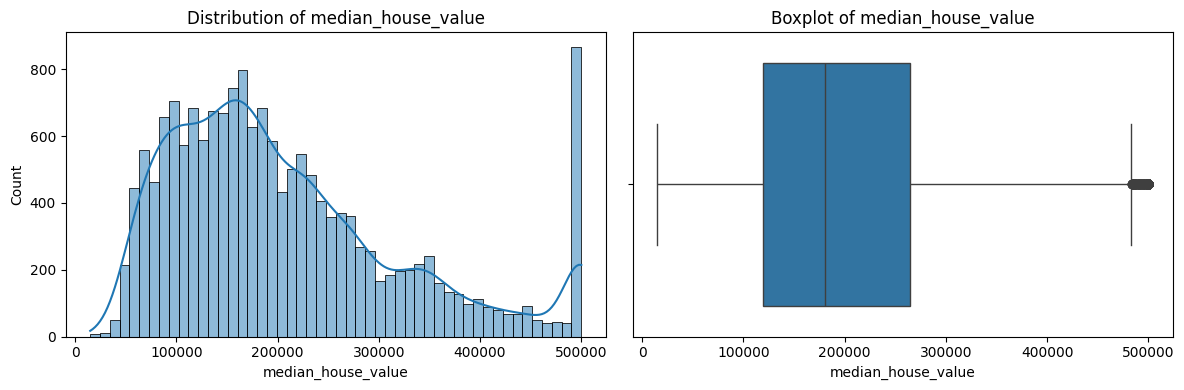

In [10]:
# Target distribution
# Note: house values are capped at 500,001 in this dataset -> visible spike at the right end
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["median_house_value"], bins=50, kde=True, ax=ax[0])
ax[0].set_title("Distribution of median_house_value")
sns.boxplot(x=df["median_house_value"], ax=ax[1])
ax[1].set_title("Boxplot of median_house_value")
plt.tight_layout()
plt.show()

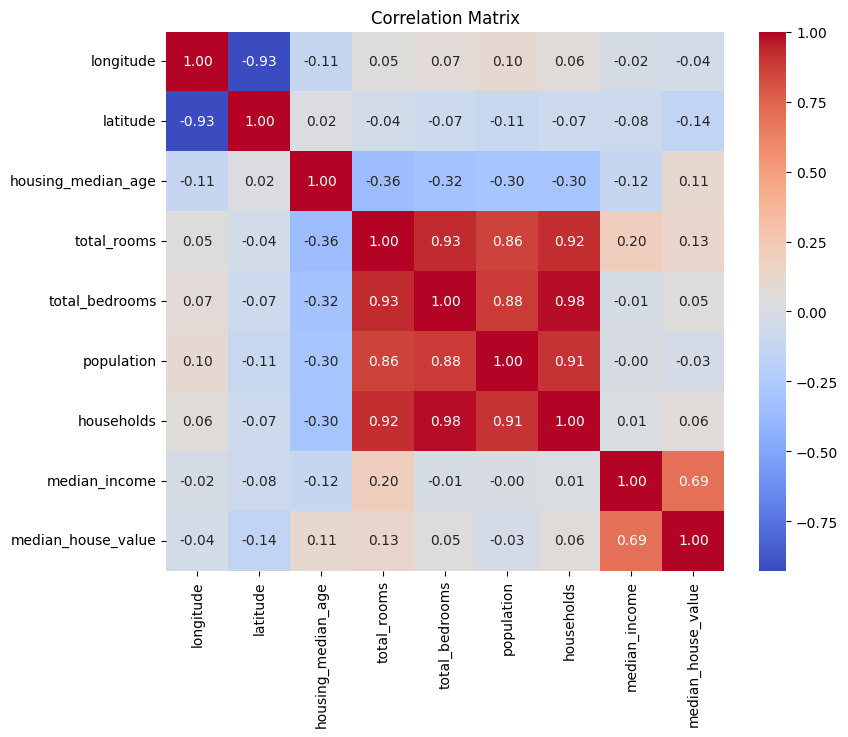

In [11]:
# Correlation heatmap -> which features relate most to the target?
# (median_income is usually the strongest predictor)
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 4. Create Features (X) and Target (y)

In [12]:
# Features: all columns except the target
X = df.drop("median_house_value", axis=1)
# or: X = df.drop(columns=['median_house_value'])

print(X.shape)
X.head()

(17000, 8)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250


In [13]:
# Target
y = df["median_house_value"]
print(y.shape)
y.head()

(17000,)


,median_house_value
0,66900.0
1,80100.0
2,85700.0
3,73400.0
4,65500.0


## 5. Train-Test Split (80% / 20%)

In [14]:
# Split BEFORE scaling -> test data must stay unseen (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (13600, 8) (13600,)
Test : (3400, 8) (3400,)


## 6. Scaling / Normalization
Brings all features to the same scale so that each gets equal importance and gradient descent converges faster.

- `fit_transform` on **train** → learns mean & std from train only
- `transform` on **test** → reuses train's mean & std (never `fit` on test)
- **Target is also scaled** – raw values (~200,000) give a huge loss (~10¹⁰) and unstable training. Predictions are converted back to dollars using `inverse_transform`.

In [15]:
# --- Feature scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # MISSING STEP in original: transform test with train stats

# --- Target scaling (needs 2D input -> reshape) ---
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1))

print("Mean of scaled train features (≈0):", X_train_scaled.mean(axis=0).round(2))
print("Std  of scaled train features (≈1):", X_train_scaled.std(axis=0).round(2))

Mean of scaled train features (≈0): [-0. -0. -0. -0. -0. -0. -0. -0.]
Std  of scaled train features (≈1): [1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Build the ANN Model

**Number of neurons in output layer**
- Regression = 1
- Binary classification = 1
- Multiclass classification = number of classes

**Steps in TensorFlow for building a model**
1. Define model (`Sequential`)
2. Add layers & neurons
3. Compile (loss, optimizer, metrics)
4. Fit on training data

> Industry mostly uses TensorFlow; research mostly uses PyTorch.

In [16]:
# 1. Define Model (Sequential)
model = Sequential(name="house_price_ann")

# 2. Add Layers & Neurons
# Input layer: shape = number of features (8). Using Input() avoids the Keras warning from `input_dim`.
model.add(Input(shape=(X_train_scaled.shape[1],)))

# Hidden layers: ReLU = non-linear activation (any non-linear activation works, ReLU is the common default)
model.add(Dense(units=64, activation="relu"))   # hidden layer 1
model.add(Dense(units=32, activation="relu"))   # hidden layer 2
model.add(Dense(units=16, activation="relu"))   # hidden layer 3

# Output layer: regression => 1 neuron + linear activation (no squashing of the predicted value)
model.add(Dense(units=1, activation="linear"))

model.summary()

Model: "house_price_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the model
- **Loss:** Mean Squared Error (standard for regression)
- **Optimizer:** Adam (adaptive learning rate)
- **Metric:** MAE (easier to interpret than MSE)

In [17]:
# 3. Compile Model
model.compile(
    loss="mean_squared_error",
    optimizer="adam",
    metrics=["mae"]
)

### Train the model
- `validation_split=0.2` → 20% of *train* data is held out to monitor overfitting (test set remains untouched)
- `EarlyStopping` → stops when validation loss stops improving and restores the best weights
- `batch_size=32` → mini-batch gradient descent (`1` = stochastic, `len(X_train)` = batch gradient descent)

In [18]:
# Early stopping: stop if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 4. Fit Model on training data
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,            # upper limit; early stopping decides the real number
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4101 - mae: 0.4633 - val_loss: 0.3030 - val_mae: 0.3915
Epoch 2/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2933 - mae: 0.3855 - val_loss: 0.2768 - val_mae: 0.3707
Epoch 3/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2733 - mae: 0.3700 - val_loss: 0.2646 - val_mae: 0.3607
Epoch 4/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2622 - mae: 0.3607 - val_loss: 0.2564 - val_mae: 0.3539
Epoch 5/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2539 - mae: 0.3542 - val_loss: 0.2504 - val_mae: 0.3475
Epoch 6/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2473 - mae: 0.3486 - val_loss: 0.2441 - val_mae: 0.3418
Epoch 7/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2409 - mae: 0.3427 - val_loss: 0.2373 - val_mae: 0.3374
Epoch 8/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2357 - mae: 0.3380 - val_loss: 0.2334 - val_mae: 0.3343
Epoch 9/100
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

In [19]:
# Sanity check: number of mini-batches per epoch (on 80% of train after validation split)
steps_per_epoch = int(len(X_train_scaled) * 0.8 / 32)
print("Approx. batches per epoch:", steps_per_epoch)
print("Epochs actually run      :", len(history.history["loss"]))

Approx. batches per epoch: 340
Epochs actually run      : 62


## 8. Learning Curves
Train loss and validation loss should both decrease. A growing gap between them signals overfitting.

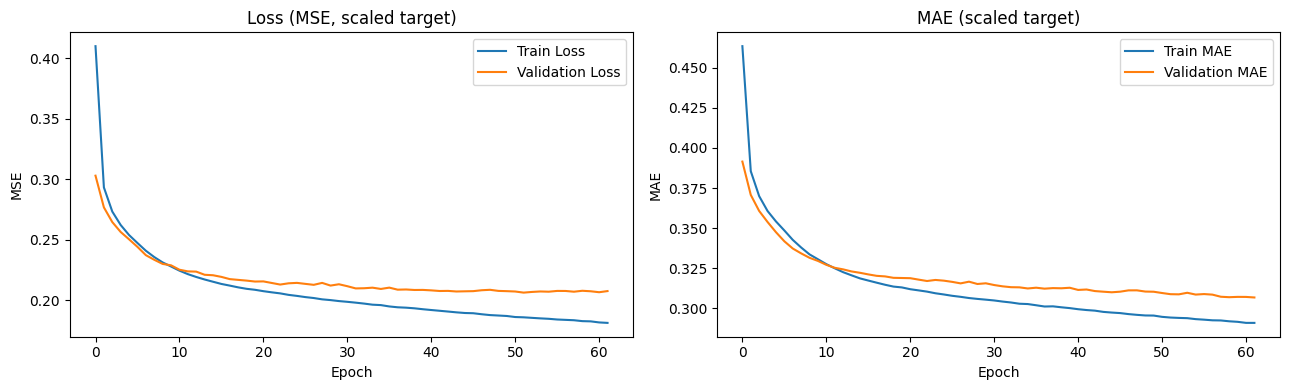

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(history.history["loss"], label="Train Loss")
ax[0].plot(history.history["val_loss"], label="Validation Loss")
ax[0].set_title("Loss (MSE, scaled target)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MSE"); ax[0].legend()

ax[1].plot(history.history["mae"], label="Train MAE")
ax[1].plot(history.history["val_mae"], label="Validation MAE")
ax[1].set_title("MAE (scaled target)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("MAE"); ax[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluate on the Test Set
Predictions are made on scaled data, then converted **back to dollars** so the metrics are meaningful.

- **RMSE** – typical error in $ (penalises large errors)
- **MAE** – average absolute error in $
- **R²** – fraction of variance explained (1.0 = perfect, 0 = same as predicting the mean)

In [21]:
# Predict on scaled test features, then inverse-transform back to actual $ values
y_pred_scaled = model.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled).ravel()
y_true = y_test.values

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print(f"MSE  : {mse:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"MAE  : ${mae:,.0f}")
print(f"R²   : {r2:.4f}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE  : 2,773,823,539
RMSE : $52,667
MAE  : $35,933
R²   : 0.7979


### 📏 How to read these metrics (value ranges)
- **R²** → unitless, usually between **0 and 1** (1 = perfect). The only metric here that lives in a fixed range.
- **MAE / RMSE** → in the **same unit as the target** (here **$**). They are *not* limited to 0–1.
- **MSE** → in **$²** (RMSE squared), so it looks huge. Use RMSE instead.
- The 0–1 looking values in the training logs (e.g. `loss: 0.17`, `mae: 0.28`) are in **scaled target units** (standardised, not dollars). Converting back with `inverse_transform` gives $.
- Rule of thumb: compare MAE/RMSE with the average house price (~$207k) → MAE ≈ 17%, RMSE ≈ 25%.

## 10. Actual vs Predicted & Residual Analysis

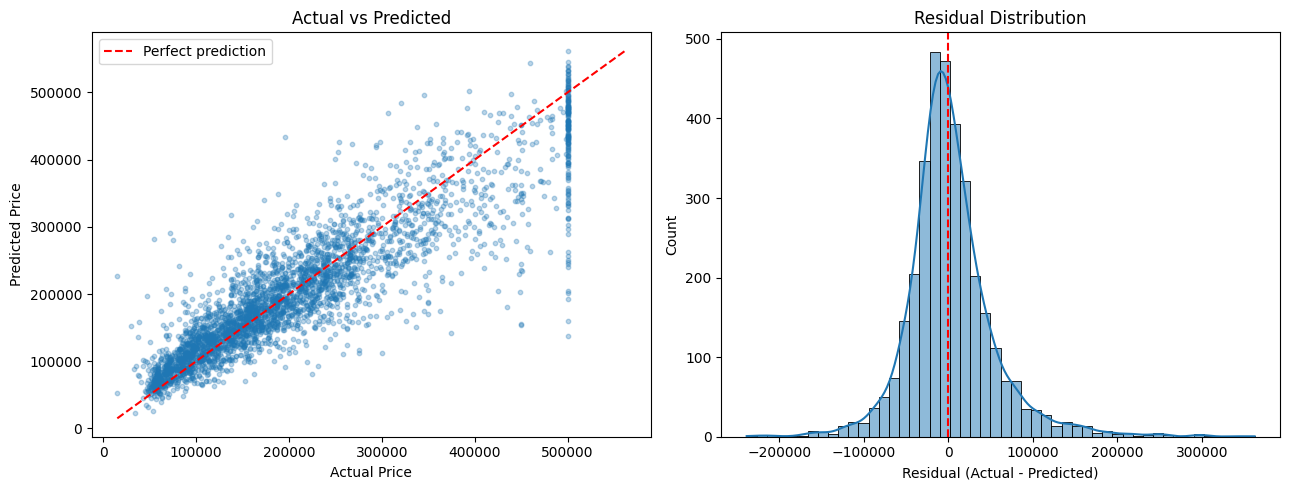

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted: points close to the red line = good predictions
ax[0].scatter(y_true, y_pred, alpha=0.3, s=10)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax[0].plot(lims, lims, "r--", label="Perfect prediction")
ax[0].set_xlabel("Actual Price"); ax[0].set_ylabel("Predicted Price")
ax[0].set_title("Actual vs Predicted"); ax[0].legend()

# Residuals (actual - predicted): should be centred around 0 with no clear pattern
residuals = y_true - y_pred
sns.histplot(residuals, bins=50, kde=True, ax=ax[1])
ax[1].axvline(0, color="r", linestyle="--")
ax[1].set_title("Residual Distribution")
ax[1].set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

In [23]:
# Side-by-side comparison for a few test samples
comparison = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred.round(0),
})
comparison["Error"] = (comparison["Actual"] - comparison["Predicted"]).round(0)
comparison["Error %"] = (comparison["Error"].abs() / comparison["Actual"] * 100).round(1)
comparison.head(10)

,Actual,Predicted,Error,Error %
0,97300.0,136285.0,-38985.0,40.1
1,270800.0,255166.0,15634.0,5.8
2,89000.0,89108.0,-108.0,0.1
3,124600.0,135524.0,-10924.0,8.8
4,386500.0,369077.0,17423.0,4.5
5,500001.0,454992.0,45009.0,9.0
6,500001.0,405016.0,94985.0,19.0
7,147800.0,126182.0,21618.0,14.6
8,241200.0,259998.0,-18798.0,7.8
9,195800.0,230925.0,-35125.0,17.9


## 11. Save Model & Scalers
Both scalers must be saved along with the model – new data has to be scaled exactly the same way at inference time.

In [24]:
os.makedirs("artifacts", exist_ok=True)

model.save("artifacts/house_price_ann.keras")
joblib.dump(scaler,   "artifacts/feature_scaler.joblib")
joblib.dump(y_scaler, "artifacts/target_scaler.joblib")
joblib.dump(list(X.columns), "artifacts/feature_columns.joblib")

print("Saved files:", os.listdir("artifacts"))

Saved files: ['feature_scaler.joblib', 'target_scaler.joblib', 'feature_columns.joblib', 'house_price_ann.keras']


## 12. Predict the Price of a New House (Inference)

In [25]:
from tensorflow.keras.models import load_model

# Load saved artifacts (this is what a deployed app / API would do)
loaded_model   = load_model("artifacts/house_price_ann.keras")
loaded_scaler  = joblib.load("artifacts/feature_scaler.joblib")
loaded_y_scaler = joblib.load("artifacts/target_scaler.joblib")
feature_cols   = joblib.load("artifacts/feature_columns.joblib")


def predict_house_price(house: dict) -> float:
    """Predict median house value (in $) from a dict of raw feature values."""
    input_df = pd.DataFrame([house])[feature_cols]            # keep same column order as training
    input_scaled = loaded_scaler.transform(input_df)          # scale with TRAIN stats
    pred_scaled = loaded_model.predict(input_scaled, verbose=0)
    return float(loaded_y_scaler.inverse_transform(pred_scaled)[0][0])  # back to $


# Example: a new house (raw, unscaled values)
new_house = {
    "longitude": -118.30,
    "latitude": 34.05,
    "housing_median_age": 25.0,
    "total_rooms": 2500.0,
    "total_bedrooms": 500.0,
    "population": 1400.0,
    "households": 480.0,
    "median_income": 4.5,
}

print(f"Predicted house price: ${predict_house_price(new_house):,.0f}")

Predicted house price: $246,799


---
## 13. Hyperparameter Tuning with Optuna (to improve R²)

**Plan**
1. *(Optional)* Engineer 3 extra features → often a big boost for this dataset
2. Let Optuna search: layers, units, activation, dropout, L2, learning rate, batch size, loss
3. Tune on a **validation split of the train data only** → the test set stays untouched
4. Retrain with best parameters → compare against the baseline on the test set

> Install once in Colab: `!pip install optuna`

In [26]:
!pip install optuna      # <- uncomment in Colab if not installed
import json
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)   # keep output clean

# Save baseline metrics now (variables from Section 9) so we can compare later
baseline = {"RMSE": rmse, "MAE": mae, "R2": r2}
print("Baseline:", {k: round(v, 4) for k, v in baseline.items()})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.2 MB/s eta 0:00:00
Baseline: {'RMSE': np.float64(52667.1011), 'MAE': 35932.7962, 'R2': 0.7979}


### 13.1 Feature Engineering (optional but recommended)
Raw totals (`total_rooms`, `population`) depend on block size. **Ratios** describe the houses better:
- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`

Set `USE_FEATURE_ENGINEERING = False` to tune on the original 8 features only.

In [27]:
USE_FEATURE_ENGINEERING = True


def add_features(data: pd.DataFrame) -> pd.DataFrame:
    """Add ratio features. Used for training AND inference (must stay identical)."""
    d = data.copy()
    if USE_FEATURE_ENGINEERING:
        d["rooms_per_household"]      = d["total_rooms"] / d["households"]
        d["bedrooms_per_room"]        = d["total_bedrooms"] / d["total_rooms"]
        d["population_per_household"] = d["population"] / d["households"]
    return d


X_train_fe = add_features(X_train)
X_test_fe  = add_features(X_test)

# New scaler for the new feature set (fit on train only, as before)
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled  = scaler_fe.transform(X_test_fe)

# Target scaling is unchanged -> reuse y_scaler / y_train_scaled from Section 6
print("Features used:", list(X_train_fe.columns))
print("Train shape  :", X_train_fe_scaled.shape)

Features used: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Train shape  : (13600, 11)


### 13.2 Define the model builder and Optuna objective
- **Objective** = validation **MSE** (scaled target) → Optuna *minimises* it
- Test data is **never** used inside the search
- `loss` is also tuned: `mse` vs `huber` (Huber is less sensitive to outliers, e.g. the $500k cap)

In [29]:
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.layers import Dropout

# Hold out a validation set from TRAIN data for the search
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_fe_scaled, y_train_scaled, test_size=0.2, random_state=SEED
)

MAX_EPOCHS_TRIAL = 60     # per trial (early stopping usually stops sooner)
N_TRIALS = 10             # more trials = better search but slower (try 10 for a quick run)


def build_model(params: dict, input_dim: int) -> Sequential:
    """Build + compile an ANN from a dict of hyperparameters."""
    l2 = regularizers.l2(params["l2"])
    m = Sequential()
    m.add(Input(shape=(input_dim,)))
    for i in range(params["n_layers"]):
        m.add(Dense(params[f"units_l{i}"], activation=params["activation"], kernel_regularizer=l2))
        if params["dropout"] > 0:
            m.add(Dropout(params["dropout"]))
    m.add(Dense(1, activation="linear"))
    m.compile(
        loss=params["loss"],
        optimizer=optimizers.Adam(learning_rate=params["lr"]),
        metrics=["mae"],
    )
    return m


def objective(trial: optuna.Trial) -> float:
    tf.keras.backend.clear_session()     # free memory between trials

    params = {
        "n_layers":   trial.suggest_int("n_layers", 1, 4),
        "activation": trial.suggest_categorical("activation", ["relu", "elu"]),
        "dropout":    trial.suggest_float("dropout", 0.0, 0.3, step=0.05),
        "l2":         trial.suggest_float("l2", 1e-6, 1e-2, log=True),
        "lr":         trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
        "loss":       trial.suggest_categorical("loss", ["mean_squared_error", "huber"]),
    }
    for i in range(params["n_layers"]):
        params[f"units_l{i}"] = trial.suggest_categorical(f"units_l{i}", [16, 32, 64, 128, 256])

    m = build_model(params, X_tr.shape[1])
    m.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS_TRIAL,
        batch_size=params["batch_size"],
        callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
        verbose=0,
    )

    # Same metric for every trial (even if the training loss differs): validation MSE
    val_pred = m.predict(X_val, verbose=0)
    return float(mean_squared_error(y_val, val_pred))

### 13.3 Run the search
⏱️ Takes roughly **15–30 min** on Colab CPU for 30 trials (use a GPU runtime or lower `N_TRIALS` to speed up).

In [30]:
study = optuna.create_study(
    direction="minimize",                              # lower validation MSE = better
    sampler=optuna.samplers.TPESampler(seed=SEED),     # smart sampler (learns from past trials)
    study_name="house_price_ann",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best trial #   :", study.best_trial.number)
print("Best val MSE   :", round(study.best_value, 4), "(scaled units)")
print("Best params    :")
for k, v in study.best_params.items():
    print(f"   {k:12s}: {v}")

  0%|          | 0/10 [00:00<?, ?it/s]

Best trial #   : 4
Best val MSE   : 0.1938 (scaled units)
Best params    :
   n_layers    : 2
   activation  : relu
   dropout     : 0.2
   l2          : 3.5488995212428855e-05
   lr          : 0.0009866147353327387
   batch_size  : 128
   loss        : mean_squared_error
   units_l0    : 64
   units_l1    : 256


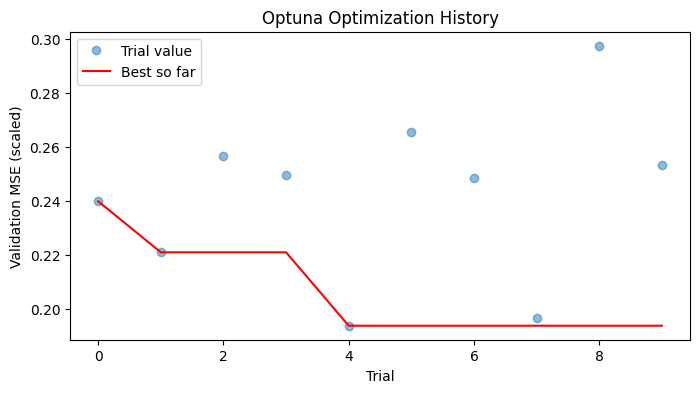

/tmp/ipykernel_1468/1417394509.py:12: UserWarning: Some regimes for parameter `units_l3` have less than 2 trials. The importance of the parameter may be inaccurate.
  importances = optuna.importance.get_param_importances(study)


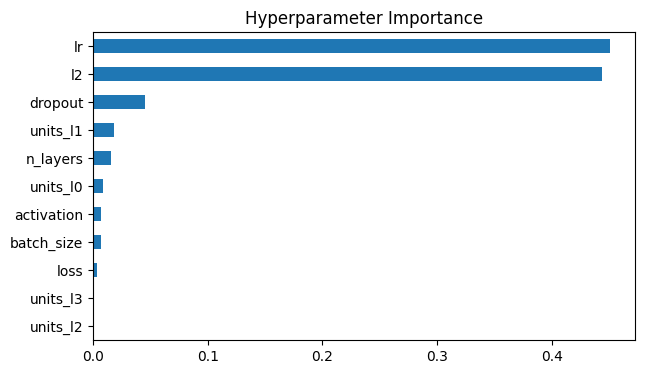

In [31]:
# Optimisation history: best value should go down over trials
trials_df = study.trials_dataframe()
plt.figure(figsize=(8, 4))
plt.plot(trials_df["number"], trials_df["value"], "o", alpha=0.5, label="Trial value")
plt.plot(trials_df["number"], trials_df["value"].cummin(), "r-", label="Best so far")
plt.xlabel("Trial"); plt.ylabel("Validation MSE (scaled)")
plt.title("Optuna Optimization History"); plt.legend()
plt.show()

# Which hyperparameters mattered most?
try:
    importances = optuna.importance.get_param_importances(study)
    pd.Series(importances).sort_values().plot(kind="barh", figsize=(7, 4), title="Hyperparameter Importance")
    plt.show()
except Exception as e:
    print("Importance plot skipped:", e)

## 14. Train the Final Model with Best Parameters
Retrain with the best hyperparameters (more epochs allowed; early stopping picks the best one), then evaluate **once** on the test set.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 0 (0.00 B)

Epochs run: 120


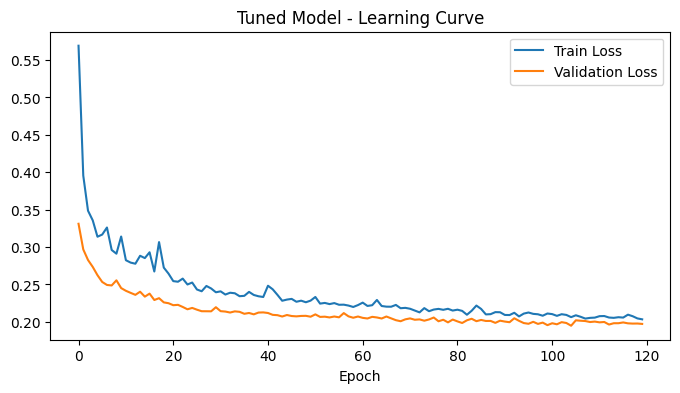

In [32]:
best_params = study.best_params.copy()
# Optuna returns only units for layers actually used -> build_model reads units_l0..units_l{n-1}

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

tuned_model = build_model(best_params, X_train_fe_scaled.shape[1])
tuned_model.summary()

tuned_history = tuned_model.fit(
    X_train_fe_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=best_params["batch_size"],
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0,
)
print("Epochs run:", len(tuned_history.history["loss"]))

plt.figure(figsize=(8, 4))
plt.plot(tuned_history.history["loss"], label="Train Loss")
plt.plot(tuned_history.history["val_loss"], label="Validation Loss")
plt.title("Tuned Model - Learning Curve"); plt.xlabel("Epoch"); plt.legend()
plt.show()

## 15. Baseline vs Tuned Model (Test Set)

In [34]:
# Predict -> inverse-transform to $ -> metrics
tuned_pred = y_scaler.inverse_transform(tuned_model.predict(X_test_fe_scaled, verbose=0)).ravel()

tuned = {
    "RMSE": float(np.sqrt(mean_squared_error(y_true, tuned_pred))),
    "MAE":  float(mean_absolute_error(y_true, tuned_pred)),
    "R2":   float(r2_score(y_true, tuned_pred)),
}

compare = pd.DataFrame({"Baseline ANN": baseline, "Tuned ANN": tuned})
compare["Change"] = compare["Tuned ANN"] - compare["Baseline ANN"]
print(compare.round(4))
print(f"\nR² improvement: {tuned['R2'] - baseline['R2']:+.4f}  |  "
      f"RMSE change: ${tuned['RMSE'] - baseline['RMSE']:+,.0f}  |  MAE change: ${tuned['MAE'] - baseline['MAE']:+,.0f}")

      Baseline ANN   Tuned ANN    Change
RMSE    52667.1011  52015.6326 -651.4685
MAE     35932.7962  35974.2801   41.4838
R2          0.7979      0.8028    0.0050

R² improvement: +0.0050  |  RMSE change: $-651  |  MAE change: $+41


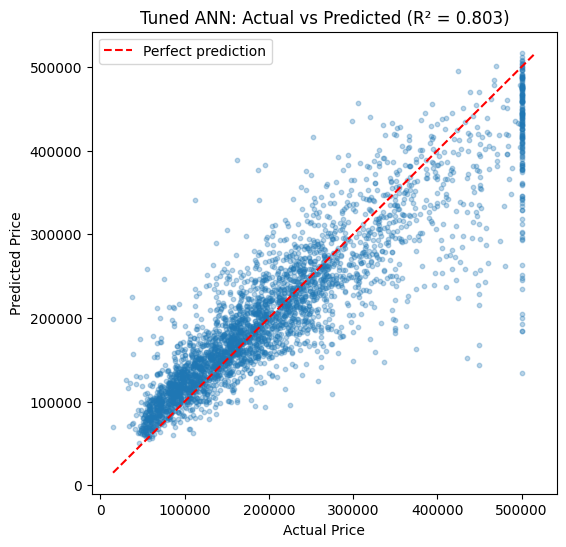

In [35]:
# Actual vs Predicted for the tuned model
plt.figure(figsize=(6, 6))
plt.scatter(y_true, tuned_pred, alpha=0.3, s=10)
lims = [min(y_true.min(), tuned_pred.min()), max(y_true.max(), tuned_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title(f"Tuned ANN: Actual vs Predicted (R² = {tuned['R2']:.3f})")
plt.legend(); plt.show()

## 16. Save Tuned Model & Predict with It

In [36]:
os.makedirs("artifacts", exist_ok=True)

tuned_model.save("artifacts/house_price_ann_tuned.keras")
joblib.dump(scaler_fe, "artifacts/feature_scaler_tuned.joblib")      # scaler for the engineered feature set
with open("artifacts/best_params.json", "w") as f:
    json.dump({**best_params, "use_feature_engineering": USE_FEATURE_ENGINEERING}, f, indent=2)
# target scaler (target_scaler.joblib) was already saved in Section 11 and is unchanged

print("Saved:", sorted(os.listdir("artifacts")))

Saved: ['best_params.json', 'feature_columns.joblib', 'feature_scaler.joblib', 'feature_scaler_tuned.joblib', 'house_price_ann.keras', 'house_price_ann_tuned.keras', 'target_scaler.joblib']


In [37]:
# Load tuned artifacts and predict (what a deployed app would do)
tuned_loaded   = load_model("artifacts/house_price_ann_tuned.keras")
scaler_loaded  = joblib.load("artifacts/feature_scaler_tuned.joblib")
y_scaler_loaded = joblib.load("artifacts/target_scaler.joblib")


def predict_house_price_tuned(house: dict) -> float:
    """Predict median house value ($) with the tuned model from RAW feature values."""
    input_df = add_features(pd.DataFrame([house])[list(X.columns)])   # same feature engineering as training
    input_scaled = scaler_loaded.transform(input_df)
    pred_scaled = tuned_loaded.predict(input_scaled, verbose=0)
    return float(y_scaler_loaded.inverse_transform(pred_scaled)[0][0])


print(f"Baseline model prediction: ${predict_house_price(new_house):,.0f}")
print(f"Tuned model prediction   : ${predict_house_price_tuned(new_house):,.0f}")

Baseline model prediction: $246,799
Tuned model prediction   : $243,239


## ✅ Summary
- Cleaned/explored data → split → scaled (train-fit only) → trained ANN with early stopping
- Evaluated on unseen test data using RMSE, MAE, R² in real dollars
- Tuned with **Optuna** (+ ratio features) and compared baseline vs tuned on the same test set
- Saved models + scalers → reusable `predict_house_price()` / `predict_house_price_tuned()`

**Further ideas**
- Compare against baselines (Linear Regression, Random Forest, XGBoost)
- Log-transform the target; cap/handle the $500k ceiling
- Try more Optuna trials or KerasTuner